In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pickle

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

def save_obj(obj, name ):
    with open('/mnt/scratch/scratch/abh_model/MF/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name ):
    with open('/mnt/scratch/scratch/abh_model/MF/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 'E': -80., #check
       ## Time costants
       'Cm': 16,
       'tau_n': 8,
       'gamma': 0.00025,  
       'epsilon': 0.0001,
       'tau_I': 1
      }

def m_inf(V):
    return 1.0/(1.0+np.exp((Par['Cmna']-V)/Par['DCmna']))

def n_inf(V):
    return 1.0/(1.0+np.exp((Par['Cnk']-V)/Par['DCnk']))

def h(n):
    return 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n - 0.4)))

def I_K_form(V,n,K_o,K_i):
    return (Par['g_Kl']+Par['g_K']*n)*(V- 26.64*np.log(K_o/K_i)) 

def I_Na_form(V,Na_o,Na_i,n):
    return (Par['g_Nal']+Par['g_Na']*m_inf(V)*h(n))*(V- 26.64*np.log(Na_o/Na_i))

def I_Cl_form(V):
    return Par['g_Cl']*(V+ 26.64*np.log(Par['Cl_o0']/Par['Cl_i0'])) 

def I_pump_form(Na_i,K_o):
    return Par['rho']*(1.0/(1.0+np.exp((Par['Cnap'] - Na_i) / Par['DCnap']))*(1.0/(1.0+np.exp((Par['Ckp'] - K_o)/Par['DCkp'])))) 

def V_dot_form(I_Na,I_K,I_Cl,I_pump):
    return (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump) 

def mean_field_model(z,t,kb,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input): 
    x = z[0]
    V = z[1]
    n = z[2]
    DK_i = z[3]
    Kg = z[4]
    K_bath= kb
    eta_bar_val= eta
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DK_i 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DK_i
    K_i = Par['K_i0'] + DK_i 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    I_K = I_K_form(V,n,K_o,K_i)
    I_Na = I_Na_form(V,Na_o,Na_i,n)
    I_Cl = I_Cl_form(V)
    I_pump = I_pump_form(Na_i,K_o)
    
    #%%%%%% Equations      
    Vdot = (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump)    
    if V <= Vstar:
        dV = Vdot - R_minus*x**2 + eta_bar_val
        dx = Delta + 2*R_minus*(V-c_minus)*x
        
    else:
        dV = Vdot - R_plus*x**2 + eta_bar_val
        dx = Delta + 2*R_plus*(V-c_plus)*x 
    rr=R_minus*x/np.pi + Input
    ninf=n_inf(V)
    
    dV+= J*(rr)*(E-V)
    dx+= -J*(rr)*x
    dn = (ninf - n) / Par['tau_n'] 
    dDK_i = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dx,dV,dn,dDK_i,dKg]
    
    return dz   

def simulate(k, J, eta, Delta, E, z0, Input=0, c_minus=-44.240, c_plus=-20.400, R_minus=0.337, R_plus=-0.381, Vstar=-31):
    #z0 Initial Conditions [x, V, n, DKi, Kg]
    # Simulation time
    min_2_sim=15
    min_2_cut=0
    Np= int(min_2_sim*60*1000) #min in milliseconds
    Np_left= int(min_2_cut*60*1000) #min in milliseconds
    t = np.linspace(0,Np,Np*1)

    #Parabolas coefficients
    z = odeint(mean_field_model,z0,t, args=(k,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input))

    Meanfield={}
    Meanfield['x']=z[:,0]
    Meanfield['V']=z[:,1]
    Meanfield['n']=z[:,2]
    Meanfield['DK_i']=z[:,3]
    Meanfield['Kg']=z[:,4]
    Meanfield['Par']={}
    Meanfield['Par']['Kbath']=k
    Meanfield['Par']['J']=J
    Meanfield['Par']['eta']=eta
    Meanfield['Par']['Delta']=Delta
    Meanfield['Par']['E']=E
    Meanfield['Par']['z0']=z0
    
    return Meanfield

In [68]:
k=15.5
J=0.01
eta=0
Delta=1

E=0

z0=[ 3.68142914e+01, -7.08166250e+01,  5.32160179e-02, -2.31103432e-01, 7.92862147e+00]
#Different parameters
R_minus=0.001
R_plus= -0.01
c_minus=-44.24
c_plus=-20.4


MF=simulate(k, J, eta, Delta, E, z0,c_minus=c_minus,c_plus=c_plus,R_minus=R_minus,R_plus=R_plus)

In [69]:
x=MF['x']
V=MF['V']
n=MF['n']
DKi=MF['DK_i']
Kg=MF['Kg']

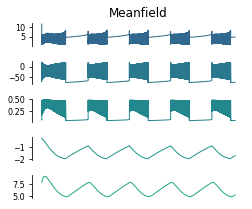

In [70]:
fig = plt.figure(figsize=(3.6,3.))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
path='/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/Figures/Fig6/'
#plt.savefig(path+'Fig6_regime_MF.pdf',dpi=300,transparent=True)
plt.show()

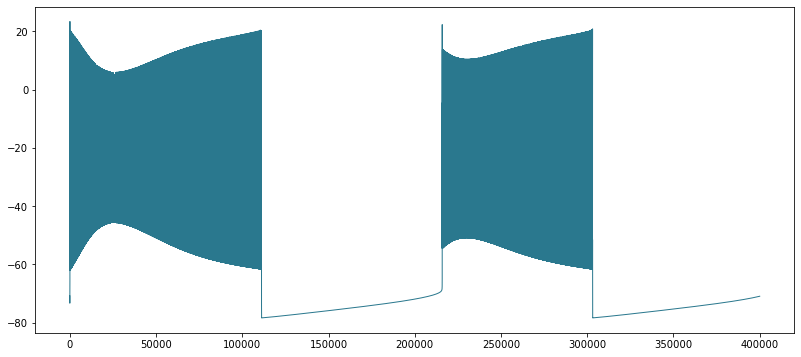

In [72]:
plt.figure(figsize=(13.6,6.))
plt.plot(V[:400000],c=viridis(6),linewidth=1)

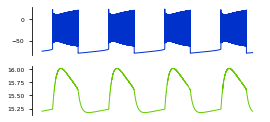

In [78]:
beta= Par['w_i'] / Par['w_o']
Kext = Par['K_o0'] + -beta * DKi + Kg

duration=int(len(V)/15*12)

fig = plt.figure(figsize=(3.8,1.8))

ax1 = fig.add_subplot(211)
ax1.plot(V[-duration:],c='#0032cb',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=6)

ax1 = fig.add_subplot(212)
ax1.plot(Kext[-duration:],c='#65cc00',linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=6)

plt.tight_layout()
path='/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/Figures/Fig4/'
plt.savefig(path+'Fig4_MF.pdf')
plt.show()